In [1]:
import os
import pandas as pd
import numpy as np

base = os.getcwd()
results = os.path.join(base, "results")
carpetas = os.listdir(results)

# Inicializar DataFrame vacío
df1 = pd.DataFrame(columns=['Simulation', 'Points', 'U', 'P'])
for carpeta in carpetas:
    resultados_csv = os.path.join(results, carpeta, "postProcessing", "resultados.csv")
    
    if not os.path.exists(resultados_csv):
        print(f"Archivo no encontrado: {resultados_csv}")
        continue

    # Leer el archivo CSV
    df = pd.read_csv(resultados_csv)

    # Extraer y organizar los datos
    x = df["Points:0"].values
    y = df["Points:1"].values
    u_x = df["U:0"].values
    u_y = df["U:1"].values
    p = df["p"].values

    points = np.column_stack((x, y))
    u = np.column_stack((u_x, u_y))

    # Crear un DataFrame temporal para la nueva fila
    new_row = pd.DataFrame({'Simulation': [carpeta], 'Points': [points], 'U': [u], 'P': [p]})

    # Concatenar el DataFrame temporal con df1
    df1 = pd.concat([df1, new_row], ignore_index=True)

df1.head()

,Simulation,Points,U,P
0,motorbike_0001,"[[-4.0, -4.0], [-5.0, -4.0], [-4.0, -3.0], [-5...","[[19.9982, 0.000262957], [19.9997, 7.9429e-05]...","[1.46604, 1.44399, 1.43601, 1.41274, 1.50379, ..."
1,motorbike_0002,"[[-4.0, -4.0], [-5.0, -4.0], [-4.0, -3.0], [-5...","[[20.0002, -3.46771e-05], [20.0, -9.28308e-06]...","[0.237197, 0.24028, 0.242085, 0.243957, 0.2318..."
2,motorbike_0003,"[[-4.0, -4.0], [-5.0, -4.0], [-4.0, -3.0], [-5...","[[20.0012, -0.00017], [20.0002, -4.82344e-05],...","[0.26233, 0.277426, 0.284333, 0.296513, 0.2367..."
3,motorbike_0004,"[[-4.0, -4.0], [-5.0, -4.0], [-4.0, -3.0], [-5...","[[20.0015, -0.000204038], [20.0002, -5.83166e-...","[0.197157, 0.215166, 0.223249, 0.238241, 0.166..."
4,motorbike_0005,"[[-4.0, -4.0], [-5.0, -4.0], [-4.0, -3.0], [-5...","[[20.0007, -9.49069e-05], [20.0001, -2.63496e-...","[0.298331, 0.306849, 0.311015, 0.317275, 0.283..."


In [8]:
#---------- CARGAR SDF------------------

# Ruta al archivo pickle
file_path = 'sdf_df.pkl'

# Cargar el DataFrame desde el archivo pickle
sdf_df = pd.read_pickle(file_path)
print(sdf_df.shape)
sdf_df.head()

(100, 2)


,SDF,Simulation
1,"[[0.7034963495946034, 0.6962765423564106, 0.68...",motorbike_0001
2,"[[0.7068953807034348, 0.6996831099324539, 0.69...",motorbike_0002
3,"[[0.6970160895798077, 0.6897177285987616, 0.68...",motorbike_0003
4,"[[0.6984983339456965, 0.6911943820618199, 0.68...",motorbike_0004
5,"[[0.7009176941921822, 0.6936458183864267, 0.68...",motorbike_0005


In [3]:
### --------------- DICRETIZACIÓN DEL ESPACIO ------------------------------

# Definir espacio bidimensional
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 0.5
resolution_x, resolution_y = 200, 80

# Calcular el paso de discretización en ambos ejes
step_x = (x_max - x_min) / (resolution_x - 1)
step_y = (y_max - y_min) / (resolution_y - 1)

# Iterar sobre cada celda de la matriz y determinar si está dentro del perfil
space =np.zeros((resolution_y, resolution_x,2))

for j in range(resolution_y):
    y = y_min + j * step_y
    for i in range(resolution_x):
        x = x_min + i * step_x
        space[j, i] = [x, y]

# Convertir space a una lista de puntos para usar en la interpolación
space_points = space.reshape(-1, 2)


print("Puntos discretizados")
print(space_points)
print("Dimensión de puntos discretizados")
print(space_points.shape)

Puntos discretizados
[[-0.5        -0.5       ]
 [-0.48994975 -0.5       ]
 [-0.4798995  -0.5       ]
 ...
 [ 1.4798995   0.5       ]
 [ 1.48994975  0.5       ]
 [ 1.5         0.5       ]]
Dimensión de puntos discretizados
(16000, 2)


In [11]:
from scipy.interpolate import griddata

# Crear las columnas para almacenar los valores discretizados
CNN_df = pd.DataFrame(columns=['SDF','Ux_discretized','Uy_discretized','P_discretized'])

# Iterar sobre cada simulación
for idx, row in df1.iterrows():
    # Obtener puntos, velocidades y presiones
    points = np.array(row["Points"])
    U = np.array(row["U"])
    P = np.array(row["P"])
    sim=row["Simulation"]
    print(sim)
    
    # Interpolación de las componentes de la velocidad y la presión en la malla
    Ux_discretized = griddata(points, U[:, 0], space_points, method='linear')
    Uy_discretized = griddata(points, U[:, 1], space_points, method='linear')
    P_discretized = griddata(points, P, space_points, method='linear')

    #Redimensionar componentes de velocidad y presión
    Ux_discretized=Ux_discretized.reshape(80,200)
    Uy_discretized=Uy_discretized.reshape(80,200)
    P_discretized=P_discretized.reshape(80,200)

    #Voltear matriz para su correcto visualizado 
    Ux_discretized=np.flipud(Ux_discretized)
    Uy_discretized=np.flipud(Uy_discretized)
    P_discretized=np.flipud(P_discretized)

    #Encontrar indice
    indice=sdf_df.index[sdf_df["Simulation"] == sim].tolist()
    print(indice)

    # Obtener la matriz SDF correspondiente a la simulación actual
    sdf_matrix = np.array(sdf_df.iloc[indice[0]-1]["SDF"])
    
    # Aplicar la condición de SDF: en las celdas ocupadas por geometría (SDF < 0), no hay valores de fluido
    Ux_discretized[sdf_matrix < 0] = 0
    Uy_discretized[sdf_matrix < 0] = 0
    P_discretized[sdf_matrix < 0] = 0
    
    # Guardar los resultados en el DataFrame
    CNN_df.at[idx, "SDF"] = sdf_matrix
    CNN_df.at[idx, "Ux_discretized"] = Ux_discretized
    CNN_df.at[idx, "Uy_discretized"] = Uy_discretized
    CNN_df.at[idx, "P_discretized"] = P_discretized

motorbike_0001
[1]
motorbike_0002
[2]
motorbike_0003
[3]
motorbike_0004
[4]
motorbike_0005
[5]
motorbike_0006
[6]
motorbike_0007
[7]
motorbike_0008
[8]
motorbike_0009
[9]
motorbike_0010
[10]
motorbike_0011
[11]
motorbike_0012
[12]
motorbike_0013
[13]
motorbike_0014
[14]
motorbike_0015
[15]
motorbike_0016
[16]
motorbike_0017
[17]
motorbike_0018
[18]
motorbike_0019
[19]
motorbike_0020
[20]
motorbike_0021
[21]
motorbike_0022
[22]
motorbike_0023
[23]
motorbike_0024
[24]
motorbike_0025
[25]
motorbike_0026
[26]
motorbike_0027
[27]
motorbike_0028
[28]
motorbike_0029
[29]
motorbike_0030
[30]
motorbike_0031
[31]
motorbike_0032
[32]
motorbike_0033
[33]
motorbike_0034
[34]
motorbike_0035
[35]
motorbike_0036
[36]
motorbike_0037
[37]
motorbike_0038
[38]
motorbike_0039
[39]
motorbike_0040
[40]
motorbike_0041
[41]
motorbike_0042
[42]
motorbike_0043
[43]
motorbike_0044
[44]
motorbike_0045
[45]
motorbike_0046
[46]
motorbike_0047
[47]
motorbike_0048
[48]
motorbike_0049
[49]
motorbike_0050
[50]
motorbike

In [12]:
indice=sdf_df.index[sdf_df["Simulation"] == "motorbike21"].tolist()
print(indice)

[]


In [13]:
CNN_df.head()


,SDF,Ux_discretized,Uy_discretized,P_discretized
0,"[[0.7034963495946034, 0.6962765423564106, 0.68...","[[19.95631098769236, 19.95621516311434, 19.956...","[[0.24326960554436275, 0.24764742890561006, 0....","[[1.594409825715236, 1.5959911049250521, 1.597..."
1,"[[0.7068953807034348, 0.6996831099324539, 0.69...","[[19.96290869058813, 19.963086706262594, 19.96...","[[0.10129499542063669, 0.10365908046326175, 0....","[[0.9486583458445502, 0.9454419234207587, 0.94..."
2,"[[0.6970160895798077, 0.6897177285987616, 0.68...","[[19.906314877017206, 19.90666883940558, 19.90...","[[0.21271737101220564, 0.21822786352272347, 0....","[[2.246955038642835, 2.239644170313274, 2.2323..."
3,"[[0.6984983339456965, 0.6911943820618199, 0.68...","[[19.90831722778763, 19.908786245842236, 19.90...","[[0.1995246078619383, 0.20474866845416234, 0.2...","[[2.216749546727616, 2.207247873332896, 2.1977..."
4,"[[0.7009176941921822, 0.6936458183864267, 0.68...","[[19.930115217472217, 19.93048605068261, 19.93...","[[0.18063848928513718, 0.18502041655482712, 0....","[[1.7022665626756215, 1.6948916950064734, 1.68..."


In [14]:
# Exportad dataframe SDF
CNN_df.to_pickle('CNN_df.pkl')

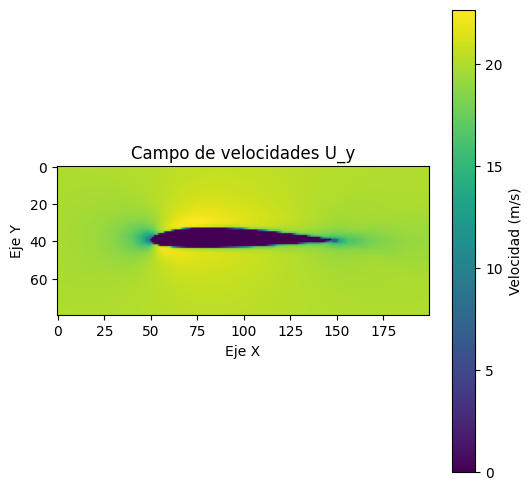

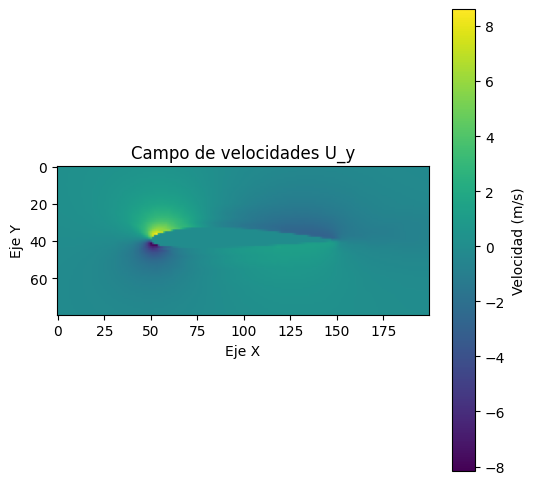

In [18]:
# -------------------- COMPROBACIÓN ----------------------
import matplotlib.pyplot as plt

U_y_plt=CNN_df["Uy_discretized"][99]
U_x_plt=CNN_df["Ux_discretized"][99]
# Crear el colormap
plt.figure(figsize=(6, 6))
plt.imshow(U_x_plt, cmap='viridis')  # 'viridis' es un colormap común, pero puedes elegir otro
plt.colorbar(label='Velocidad (m/s)')   # Agrega una barra de color para indicar la escala
plt.title('Campo de velocidades U_y')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')

# Crear el colormap
plt.figure(figsize=(6, 6))
plt.imshow(U_y_plt, cmap='viridis')  # 'viridis' es un colormap común, pero puedes elegir otro
plt.colorbar(label='Velocidad (m/s)')   # Agrega una barra de color para indicar la escala
plt.title('Campo de velocidades U_y')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')

# Mostrar el gráfico
plt.show()